# Semantic Chunk Threshold Exploration

Use this notebook to sample Guardian articles and compare chunk sizes across different `DEFAULT_SEMANTIC_BREAK_SIMILARITY_THRESHOLD` values.

Higher thresholds create more semantic breaks because the chunker splits when adjacent sentence similarity falls below the threshold. This notebook shows both raw semantic boundaries and the runtime-packed chunks used by the chunk retrieval pipeline.

In [1]:
from pathlib import Path
import math
import re
import sys

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except Exception:
    HAS_MATPLOTLIB = False

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from backend.services.chunk_retrieval_service import (
    DEFAULT_CHUNK_MAX_CHARS,
    DEFAULT_CHUNK_MIN_CHARS,
    DEFAULT_CHUNK_TARGET_CHARS,
    _pack_body_candidates,
)
from backend.text_processing.indexing.corpus import (
    DEFAULT_DB_PATH,
    DEFAULT_INDEX_DIR,
    _db_has_complete_body_text,
    _filter_articles_to_years,
    _load_guardian_articles_from_raw,
    _load_guardian_articles_from_sqlite,
)
from backend.text_processing.paragraph_splitter import normalize_paragraph_text
from backend.text_processing.semantic_chunker import (
    DEFAULT_SEMANTIC_BREAK_SIMILARITY_THRESHOLD,
    semantic_chunk_rows_from_text,
)
from backend.text_processing.svd_processor import DEFAULT_SVD_INDEX_NAME, load_svd_index

pd.set_option('display.max_columns', 80)
pd.set_option('display.max_colwidth', 220)
WORD_PATTERN = re.compile(r"\b[\w'-]+\b")
ROOT

/Users/stevenzhou/miniconda3/envs/info4300/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


PosixPath('/Users/stevenzhou/Desktop/StevenZhou/Undergraduate/INFO4300/hearhear')

## Settings

Start with a small, mixed-length sample. Set `ARTICLE_IDS` to inspect specific articles, or set `YEARS = None` to sample across the full corpus.

In [2]:
RANDOM_SEED = 4300
YEARS = [2023, 2024, 2025]
ARTICLE_IDS = []
N_ARTICLES = 10
MIN_BODY_WORDS = 700
MAX_BODY_WORDS = None
SAMPLE_BY_LENGTH = True

THRESHOLDS = sorted({
    0.10,
    0.15,
    float(DEFAULT_SEMANTIC_BREAK_SIMILARITY_THRESHOLD),
    0.25,
    0.30,
    0.35,
    0.40,
    0.50,
})

MODES = ['raw_boundaries', 'runtime_packed']
VIEW_MODE = 'runtime_packed'

print('Current default threshold:', DEFAULT_SEMANTIC_BREAK_SIMILARITY_THRESHOLD)
print('Runtime packing chars:', {'target': DEFAULT_CHUNK_TARGET_CHARS, 'min': DEFAULT_CHUNK_MIN_CHARS, 'max': DEFAULT_CHUNK_MAX_CHARS})
print('Thresholds:', THRESHOLDS)

Current default threshold: 0.2
Runtime packing chars: {'target': 1800, 'min': 500, 'max': 2500}
Thresholds: [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5]


## Load the Boundary SVD Processor

The semantic chunker uses the existing article-level SVD index to compare adjacent sentences. If this cell cannot load the index, run the app bootstrap or rebuild the SVD artifacts first.

In [3]:
try:
    svd_processor, svd_meta = load_svd_index(
        index_dir=DEFAULT_INDEX_DIR,
        index_name=DEFAULT_SVD_INDEX_NAME,
        load_articles=False,
    )
    display(Markdown(f'Loaded `{DEFAULT_SVD_INDEX_NAME}` with {svd_processor.n_docs:,} docs, {svd_processor.n_terms:,} terms, and {svd_processor.n_components} components.'))
except Exception as exc:
    svd_processor = None
    svd_meta = {}
    display(Markdown(f'Could not load `{DEFAULT_SVD_INDEX_NAME}`: `{exc}`'))

Loaded `guardian_tfidf_svd` with 66,331 docs, 82,749 terms, and 100 components.

## Draw Example Articles

In [4]:
def word_count(text):
    return len(WORD_PATTERN.findall(str(text or '')))


def load_articles(years=None):
    if DEFAULT_DB_PATH.exists() and _db_has_complete_body_text(DEFAULT_DB_PATH):
        frame = _load_guardian_articles_from_sqlite(DEFAULT_DB_PATH)
        source = 'sqlite'
    else:
        frame = _load_guardian_articles_from_raw(years=years)
        source = 'raw_csv'

    frame = _filter_articles_to_years(frame, years=years).copy()
    frame['id'] = frame['id'].astype(str)
    frame['title'] = frame.get('title', '').astype(str)
    frame['body_text'] = frame.get('body_text', '').astype(str)
    frame['body_chars'] = frame['body_text'].str.len()
    frame['body_words'] = frame['body_text'].map(word_count)
    frame = frame.loc[frame['body_words'] > 0].reset_index(drop=True)
    return frame, source


def draw_articles(frame, article_ids=None, n_articles=10, seed=4300):
    article_ids = [str(article_id) for article_id in list(article_ids or [])]
    if article_ids:
        selected = frame.loc[frame['id'].isin(article_ids)].copy()
        missing = sorted(set(article_ids) - set(selected['id'].tolist()))
        if missing:
            display(Markdown(f'Article ids not found: `{missing}`'))
        return selected.reset_index(drop=True)

    eligible = frame.loc[frame['body_words'] >= int(MIN_BODY_WORDS)].copy()
    if MAX_BODY_WORDS is not None:
        eligible = eligible.loc[eligible['body_words'] <= int(MAX_BODY_WORDS)].copy()
    if eligible.empty:
        raise ValueError('No eligible articles after body length filters.')

    if not SAMPLE_BY_LENGTH or len(eligible) <= n_articles:
        return eligible.sample(n=min(n_articles, len(eligible)), random_state=seed).reset_index(drop=True)

    bin_count = min(4, len(eligible))
    eligible['length_bin'] = pd.qcut(eligible['body_words'], q=bin_count, duplicates='drop')
    actual_bins = max(1, eligible['length_bin'].nunique())
    per_bin = max(1, math.ceil(n_articles / actual_bins))
    sampled = (
        eligible
        .groupby('length_bin', observed=True, group_keys=False)
        .sample(n=per_bin, random_state=seed, replace=False)
        .sample(frac=1, random_state=seed)
        .head(n_articles)
    )
    return sampled.drop(columns=['length_bin'], errors='ignore').reset_index(drop=True)


articles, article_source = load_articles(years=YEARS)
sample_articles = draw_articles(articles, ARTICLE_IDS, N_ARTICLES, RANDOM_SEED)

display(Markdown(f'Loaded {len(articles):,} articles from `{article_source}`. Sampled {len(sample_articles):,} articles.'))
display(sample_articles[['id', 'year', 'title', 'body_words', 'body_chars']].sort_values('body_words'))

Loaded 14,254 articles from `sqlite`. Sampled 10 articles.

,id,year,title,body_words,body_chars
0,commentisfree/2023/aug/03/kids-camp-cyberstalk-empty-nest,2023,"With my kids away, I’m expected to relax – but I’m too busy cyberstalking them",755,4075
8,commentisfree/article/2024/may/15/uk-broken-refugee-policy-children-people-smugglers,2024,The UK’s broken refugee policy is delivering vulnerable children into the hands of people smugglers,758,4599
3,commentisfree/2025/apr/02/cory-brooker-25-hour-speech-donald-trump-democrats,2025,"After months of surrender, the Democrats have finally stood up to Trump – thank you, Cory Booker",806,4810
2,australia-news/commentisfree/2024/oct/29/australian-cities-are-desperate-for-the-missing-middle-of-housing-density-but-its-not-as-simple-as-the-nimby-yimby-debate-suggests,2024,Australian cities are desperate for the ‘missing middle’ of housing density. But it’s not as simple as the nimby-yimby debate suggests,908,5692
1,commentisfree/2024/feb/29/wayne-couzens-report-misogyny-police-forces-sarah-everard,2024,I read the Couzens report expecting evidence of rank misogyny. What I found was almost worse,948,5627
7,commentisfree/2023/jan/27/madonna-64-work-choices-other-women-menopause-protections,2023,Madonna is the material proof: older women rock. So why do so many still have to stop work?,972,5473
4,commentisfree/2023/jun/22/george-osborne-austerity-children-covid-inquiry,2023,"So, George Osborne, austerity was essential? Tell that to the children still suffering its terrible effects",1081,6339
9,commentisfree/2023/mar/31/hush-money-porn-star-trump-indicted,2023,Hush money to a porn star: of course this was how Trump was indicted,1094,6242
5,commentisfree/2025/feb/06/lucy-letby-convictions-upheld-health-law-public,2025,"I don’t know if Lucy Letby’s convictions will be upheld, but I know we all have a stake in the outcome",1125,6605
6,commentisfree/2023/jul/08/smell-of-defeat-hangs-over-tory-mps-rishi-sunak-unable-to-dispel-odour,2023,"The smell of defeat hovers over Tory MPs, and Rishi Sunak is unable to dispel the odour",1464,8293


## Run Threshold Sweep

`raw_boundaries` shows only the semantic break decisions. `runtime_packed` mirrors the current retrieval pipeline by packing adjacent semantic sections up to the runtime chunk size limits.

In [5]:
if svd_processor is None:
    raise RuntimeError('This sweep needs the article-level SVD processor. Rebuild or warm the SVD artifacts first.')


def clip_text(text, max_chars=280):
    clean = normalize_paragraph_text(text)
    if len(clean) <= max_chars:
        return clean
    return clean[:max_chars].rsplit(' ', 1)[0] + '...'


def semantic_sections_for_article(article, threshold):
    article_id = str(article.get('id') or '')
    body_text = str(article.get('body_text') or '')
    raw_rows = semantic_chunk_rows_from_text(
        body_text,
        article_id=article_id,
        prefix=f'explore_{article_id}_t{str(threshold).replace(".", "_")}_sc',
        svd_processor=svd_processor,
        similarity_threshold=float(threshold),
        max_chars=DEFAULT_CHUNK_MAX_CHARS,
    )
    raw_sections = []
    for row in raw_rows:
        text = normalize_paragraph_text(row.get('paragraph'))
        if not text:
            continue
        raw_sections.append({
            'text': text,
            'source': 'raw_boundaries',
            'sentence_start_index': row.get('sentence_start_index'),
            'sentence_end_index': row.get('sentence_end_index'),
        })

    packed_sections = _pack_body_candidates(raw_sections, source='runtime_packed')
    return {
        'raw_boundaries': raw_sections,
        'runtime_packed': packed_sections,
    }


records = []
for article in sample_articles.to_dict(orient='records'):
    article_id = str(article.get('id') or '')
    for threshold in THRESHOLDS:
        sections_by_mode = semantic_sections_for_article(article, threshold)
        for mode in MODES:
            for chunk_index, section in enumerate(sections_by_mode.get(mode, [])):
                text = normalize_paragraph_text(section.get('text'))
                start_index = section.get('sentence_start_index')
                end_index = section.get('sentence_end_index')
                sentence_count = None
                if start_index is not None and end_index is not None:
                    sentence_count = int(end_index) - int(start_index) + 1
                records.append({
                    'mode': mode,
                    'threshold': float(threshold),
                    'article_id': article_id,
                    'year': article.get('year'),
                    'title': article.get('title'),
                    'article_words': int(article.get('body_words') or 0),
                    'chunk_index': chunk_index,
                    'chunk_chars': len(text),
                    'chunk_words': word_count(text),
                    'sentence_start_index': start_index,
                    'sentence_end_index': end_index,
                    'sentence_count': sentence_count,
                    'text': text,
                    'preview': clip_text(text),
                })

chunks_df = pd.DataFrame(records)
display(Markdown(f'Built {len(chunks_df):,} chunk rows across {len(THRESHOLDS)} thresholds and {len(MODES)} modes.'))
display(chunks_df.head())

Built 1,840 chunk rows across 8 thresholds and 2 modes.

,mode,threshold,article_id,year,title,article_words,chunk_index,chunk_chars,chunk_words,sentence_start_index,sentence_end_index,sentence_count,text,preview
0,raw_boundaries,0.1,commentisfree/2023/aug/03/kids-camp-cyberstalk-empty-nest,2023,"With my kids away, I’m expected to relax – but I’m too busy cyberstalking them",755,0,451,94,0,4,5,"On Sunday I dropped off my kids at camp and, all going well, I won’t see or hear from them for two weeks. This wasn’t part of my plan for the summer. Sleepaway camp, a staple of American childhood, isn’t in my backgr...","On Sunday I dropped off my kids at camp and, all going well, I won’t see or hear from them for two weeks. This wasn’t part of my plan for the summer. Sleepaway camp, a staple of American childhood, isn’t in my backgr..."
1,raw_boundaries,0.1,commentisfree/2023/aug/03/kids-camp-cyberstalk-empty-nest,2023,"With my kids away, I’m expected to relax – but I’m too busy cyberstalking them",755,1,138,30,5,6,2,"So there they are, at a lake in New Jersey, and here I am, in New York, alone. It should be good for all of us, this period of detachment.","So there they are, at a lake in New Jersey, and here I am, in New York, alone. It should be good for all of us, this period of detachment."
2,raw_boundaries,0.1,commentisfree/2023/aug/03/kids-camp-cyberstalk-empty-nest,2023,"With my kids away, I’m expected to relax – but I’m too busy cyberstalking them",755,2,692,125,7,12,6,"Unless you favour the Edwardian model and ship off your kids to boarding school as long-range training for ruining the country, parenting young children is intense. Single parenting, in the absence of immediate famil...","Unless you favour the Edwardian model and ship off your kids to boarding school as long-range training for ruining the country, parenting young children is intense. Single parenting, in the absence of immediate famil..."
3,raw_boundaries,0.1,commentisfree/2023/aug/03/kids-camp-cyberstalk-empty-nest,2023,"With my kids away, I’m expected to relax – but I’m too busy cyberstalking them",755,3,50,11,13,13,1,So why am I drifting around my house like a ghost?,So why am I drifting around my house like a ghost?
4,raw_boundaries,0.1,commentisfree/2023/aug/03/kids-camp-cyberstalk-empty-nest,2023,"With my kids away, I’m expected to relax – but I’m too busy cyberstalking them",755,4,1376,245,14,28,15,"The problem is partly structural. There comes a point, in parenthood, when the release of pressure is less likely to invite relief than to guarantee some kind of collapse. Without dropoff and pickup, perpetual feedin...","The problem is partly structural. There comes a point, in parenthood, when the release of pressure is less likely to invite relief than to guarantee some kind of collapse. Without dropoff and pickup, perpetual feedin..."


## Summary Tables

In [6]:
article_summary = (
    chunks_df
    .groupby(['mode', 'threshold', 'article_id', 'title', 'year', 'article_words'], dropna=False)
    .agg(
        chunk_count=('chunk_index', 'count'),
        mean_chunk_words=('chunk_words', 'mean'),
        median_chunk_words=('chunk_words', 'median'),
        p90_chunk_words=('chunk_words', lambda values: values.quantile(0.90)),
        max_chunk_words=('chunk_words', 'max'),
        mean_chunk_chars=('chunk_chars', 'mean'),
        max_chunk_chars=('chunk_chars', 'max'),
    )
    .reset_index()
)

threshold_summary = (
    article_summary
    .groupby(['mode', 'threshold'], dropna=False)
    .agg(
        sample_articles=('article_id', 'nunique'),
        mean_chunks_per_article=('chunk_count', 'mean'),
        median_chunks_per_article=('chunk_count', 'median'),
        median_chunk_words=('median_chunk_words', 'median'),
        p90_chunk_words=('p90_chunk_words', 'median'),
        max_chunk_words=('max_chunk_words', 'max'),
        max_chunk_chars=('max_chunk_chars', 'max'),
    )
    .round(1)
    .reset_index()
)

display(Markdown('### Overall by threshold and mode'))
display(threshold_summary)

display(Markdown(f'### Per-article summary for `{VIEW_MODE}`'))
display(
    article_summary
    .loc[article_summary['mode'] == VIEW_MODE]
    .sort_values(['threshold', 'article_words', 'title'])
    .round(1)
)

### Overall by threshold and mode

,mode,threshold,sample_articles,mean_chunks_per_article,median_chunks_per_article,median_chunk_words,p90_chunk_words,max_chunk_words,max_chunk_chars
0,raw_boundaries,0.10,10,8.0,8.5,102.8,258.2,434,2500
1,raw_boundaries,0.15,10,11.0,10.5,41.8,230.8,434,2470
2,raw_boundaries,0.20,10,14.4,14.0,44.8,138.2,434,2470
3,raw_boundaries,0.25,10,17.6,17.5,35.8,132.9,417,2489
4,raw_boundaries,0.30,10,22.4,23.0,30.2,85.1,422,2489
5,raw_boundaries,0.35,10,25.2,24.0,28.5,71.5,422,2487
6,raw_boundaries,0.40,10,27.8,27.5,26.0,66.6,274,1665
7,raw_boundaries,0.50,10,31.5,32.5,25.5,55.5,274,1665
8,runtime_packed,0.10,10,3.3,3.0,326.5,386.8,443,2500
9,runtime_packed,0.15,10,3.2,3.0,326.5,388.4,443,2470


### Per-article summary for `runtime_packed`

,mode,threshold,article_id,title,year,article_words,chunk_count,mean_chunk_words,median_chunk_words,p90_chunk_words,max_chunk_words,mean_chunk_chars,max_chunk_chars
81,runtime_packed,0.1,commentisfree/2023/aug/03/kids-camp-cyberstalk-empty-nest,"With my kids away, I’m expected to relax – but I’m too busy cyberstalking them",2023,755,3,251.7,260.0,346.4,368,1358.0,2072
89,runtime_packed,0.1,commentisfree/article/2024/may/15/uk-broken-refugee-policy-children-people-smugglers,The UK’s broken refugee policy is delivering vulnerable children into the hands of people smugglers,2024,758,2,379.0,379.0,395.0,399,2299.0,2339
87,runtime_packed,0.1,commentisfree/2025/apr/02/cory-brooker-25-hour-speech-donald-trump-democrats,"After months of surrender, the Democrats have finally stood up to Trump – thank you, Cory Booker",2025,806,3,268.7,323.0,326.2,327,1603.0,2052
80,runtime_packed,0.1,australia-news/commentisfree/2024/oct/29/australian-cities-are-desperate-for-the-missing-middle-of-housing-density-but-its-not-as-simple-as-the-nimby-yimby-debate-suggests,Australian cities are desperate for the ‘missing middle’ of housing density. But it’s not as simple as the nimby-yimby debate suggests,2024,908,3,302.7,332.0,374.4,385,1896.7,2445
86,runtime_packed,0.1,commentisfree/2024/feb/29/wayne-couzens-report-misogyny-police-forces-sarah-everard,I read the Couzens report expecting evidence of rank misogyny. What I found was almost worse,2024,948,3,316.0,330.0,392.4,408,1875.3,2442
...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,runtime_packed,0.5,commentisfree/2023/jan/27/madonna-64-work-choices-other-women-menopause-protections,Madonna is the material proof: older women rock. So why do so many still have to stop work?,2023,972,3,324.0,334.0,374.0,384,1823.7,2263
154,runtime_packed,0.5,commentisfree/2023/jun/22/george-osborne-austerity-children-covid-inquiry,"So, George Osborne, austerity was essential? Tell that to the children still suffering its terrible effects",2023,1081,3,360.3,359.0,391.8,400,2113.0,2251
155,runtime_packed,0.5,commentisfree/2023/mar/31/hush-money-porn-star-trump-indicted,Hush money to a porn star: of course this was how Trump was indicted,2023,1094,4,273.5,322.0,350.6,359,1560.2,2015
158,runtime_packed,0.5,commentisfree/2025/feb/06/lucy-letby-convictions-upheld-health-law-public,"I don’t know if Lucy Letby’s convictions will be upheld, but I know we all have a stake in the outcome",2025,1125,4,281.2,305.5,315.8,317,1650.8,1852


## Visual Checks

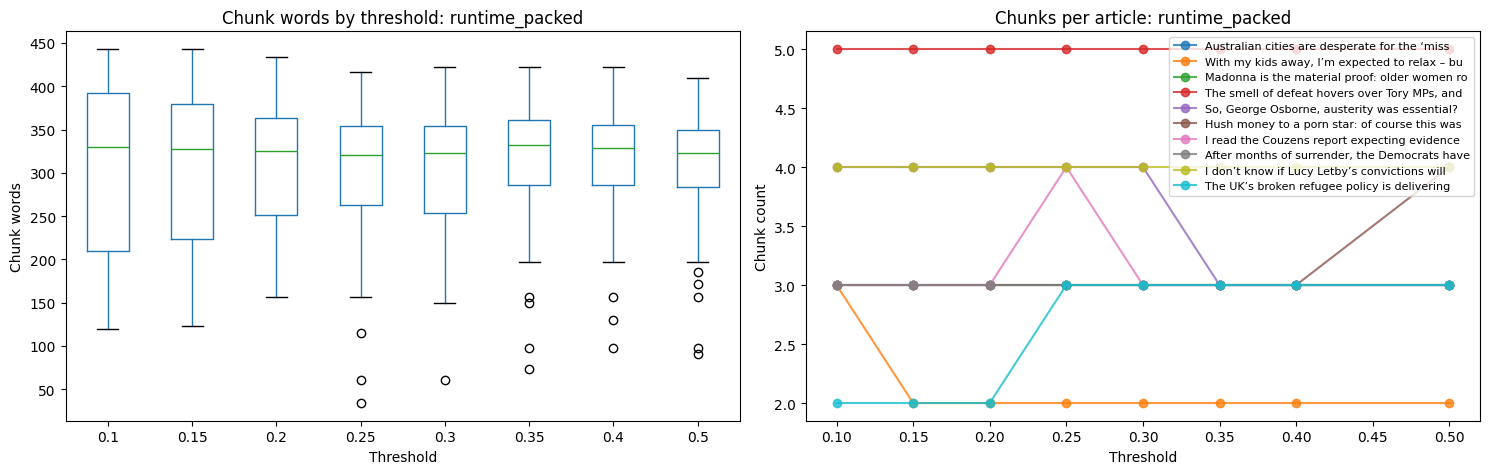

In [7]:
view_chunks = chunks_df.loc[chunks_df['mode'] == VIEW_MODE].copy()
view_article_summary = article_summary.loc[article_summary['mode'] == VIEW_MODE].copy()

if not HAS_MATPLOTLIB:
    display(Markdown('Matplotlib is not installed in this environment, so only the tables above are shown.'))
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    view_chunks.boxplot(column='chunk_words', by='threshold', ax=axes[0], grid=False)
    axes[0].set_title(f'Chunk words by threshold: {VIEW_MODE}')
    axes[0].set_xlabel('Threshold')
    axes[0].set_ylabel('Chunk words')

    for article_id, group in view_article_summary.groupby('article_id'):
        title = str(group['title'].iloc[0])[:45]
        axes[1].plot(group['threshold'], group['chunk_count'], marker='o', alpha=0.8, label=title)
    axes[1].set_title(f'Chunks per article: {VIEW_MODE}')
    axes[1].set_xlabel('Threshold')
    axes[1].set_ylabel('Chunk count')
    axes[1].legend(fontsize=8, loc='best')
    plt.suptitle('')
    plt.tight_layout()
    plt.show()

## Inspect One Article Across Thresholds

In [8]:
ARTICLE_TO_INSPECT = sample_articles.iloc[0]['id']
INSPECT_MODE = VIEW_MODE
INSPECT_THRESHOLDS = [value for value in [DEFAULT_SEMANTIC_BREAK_SIMILARITY_THRESHOLD, 0.30, 0.40, 0.50] if value in THRESHOLDS]


def rows_for_threshold(frame, article_id, threshold, mode):
    return frame.loc[
        (frame['article_id'] == str(article_id))
        & (frame['mode'] == mode)
        & np.isclose(frame['threshold'], float(threshold))
    ].sort_values('chunk_index')


def show_article_chunks(article_id=ARTICLE_TO_INSPECT, mode=INSPECT_MODE, thresholds=INSPECT_THRESHOLDS, preview_chars=650):
    article_rows = sample_articles.loc[sample_articles['id'] == str(article_id)]
    if article_rows.empty:
        raise ValueError(f'Article id not in current sample: {article_id}')
    article = article_rows.iloc[0]
    display(Markdown(f'## {article.title}\n\n`{article.id}` | {article.year} | {article.body_words:,} words | mode: `{mode}`'))

    for threshold in thresholds:
        rows = rows_for_threshold(chunks_df, article_id, threshold, mode).copy()
        rows['preview'] = rows['text'].map(lambda text: clip_text(text, preview_chars))
        display(Markdown(f'### Threshold {threshold:.2f}: {len(rows)} chunks'))
        display(rows[['chunk_index', 'chunk_words', 'chunk_chars', 'sentence_start_index', 'sentence_end_index', 'sentence_count', 'preview']])


show_article_chunks()

## With my kids away, I’m expected to relax – but I’m too busy cyberstalking them

`commentisfree/2023/aug/03/kids-camp-cyberstalk-empty-nest` | 2023 | 755 words | mode: `runtime_packed`

### Threshold 0.20: 2 chunks

,chunk_index,chunk_words,chunk_chars,sentence_start_index,sentence_end_index,sentence_count,preview
48,0,390,2078,0,20,21,"On Sunday I dropped off my kids at camp and, all going well, I won’t see or hear from them for two weeks. This wasn’t part of my plan for the summer. Sleepaway camp, a staple of American childhood, isn’t in my backgr..."
49,1,365,1997,21,43,23,"This looks quite sad written down and, I’m vaguely aware, isn’t what I’m supposed to be doing. Maybe I could get a haircut. Or lunch! People have lunch, right? Friends counsel “self-care” in the form of traditional m..."


### Threshold 0.30: 2 chunks

,chunk_index,chunk_words,chunk_chars,sentence_start_index,sentence_end_index,sentence_count,preview
105,0,390,2078,0,20,21,"On Sunday I dropped off my kids at camp and, all going well, I won’t see or hear from them for two weeks. This wasn’t part of my plan for the summer. Sleepaway camp, a staple of American childhood, isn’t in my backgr..."
106,1,365,1997,21,43,23,"This looks quite sad written down and, I’m vaguely aware, isn’t what I’m supposed to be doing. Maybe I could get a haircut. Or lunch! People have lunch, right? Friends counsel “self-care” in the form of traditional m..."


### Threshold 0.40: 2 chunks

,chunk_index,chunk_words,chunk_chars,sentence_start_index,sentence_end_index,sentence_count,preview
170,0,390,2078,0,20,21,"On Sunday I dropped off my kids at camp and, all going well, I won’t see or hear from them for two weeks. This wasn’t part of my plan for the summer. Sleepaway camp, a staple of American childhood, isn’t in my backgr..."
171,1,365,1997,21,43,23,"This looks quite sad written down and, I’m vaguely aware, isn’t what I’m supposed to be doing. Maybe I could get a haircut. Or lunch! People have lunch, right? Friends counsel “self-care” in the form of traditional m..."


### Threshold 0.50: 2 chunks

,chunk_index,chunk_words,chunk_chars,sentence_start_index,sentence_end_index,sentence_count,preview
208,0,375,1992,0,19,20,"On Sunday I dropped off my kids at camp and, all going well, I won’t see or hear from them for two weeks. This wasn’t part of my plan for the summer. Sleepaway camp, a staple of American childhood, isn’t in my backgr..."
209,1,380,2083,20,43,24,"It was an expensive bin with a lifetime guarantee – damn right I want a replacement.) This looks quite sad written down and, I’m vaguely aware, isn’t what I’m supposed to be doing. Maybe I could get a haircut. Or lun..."


## Find Candidate Thresholds

Adjust the target range to match what you want the LLM stance scorer to see. If raw boundaries look right but runtime-packed chunks are still too large, tune the packing constants rather than only the semantic threshold.

In [9]:
TARGET_MEDIAN_CHUNK_WORDS = (120, 320)
TARGET_P90_CHUNK_WORDS_MAX = 520

candidates = threshold_summary.loc[
    (threshold_summary['mode'] == VIEW_MODE)
    & (threshold_summary['median_chunk_words'] >= TARGET_MEDIAN_CHUNK_WORDS[0])
    & (threshold_summary['median_chunk_words'] <= TARGET_MEDIAN_CHUNK_WORDS[1])
    & (threshold_summary['p90_chunk_words'] <= TARGET_P90_CHUNK_WORDS_MAX)
].sort_values(['p90_chunk_words', 'median_chunk_words'])

display(Markdown(f'Candidate thresholds for `{VIEW_MODE}` with median words in {TARGET_MEDIAN_CHUNK_WORDS} and p90 <= {TARGET_P90_CHUNK_WORDS_MAX}:'))
display(candidates if not candidates.empty else threshold_summary.loc[threshold_summary['mode'] == VIEW_MODE])

Candidate thresholds for `runtime_packed` with median words in (120, 320) and p90 <= 520:

,mode,threshold,sample_articles,mean_chunks_per_article,median_chunks_per_article,median_chunk_words,p90_chunk_words,max_chunk_words,max_chunk_chars
11,runtime_packed,0.25,10,3.4,3.0,309.8,360.4,417,2489
12,runtime_packed,0.30,10,3.3,3.0,314.2,372.3,422,2489


## Notes

- Higher threshold means more breaks and usually smaller raw semantic chunks.
- `runtime_packed` can stay larger because adjacent semantic sections are packed toward `DEFAULT_CHUNK_TARGET_CHARS` and capped by `DEFAULT_CHUNK_MAX_CHARS`.
- After choosing a threshold, update `DEFAULT_SEMANTIC_BREAK_SIMILARITY_THRESHOLD` and rebuild the chunk SVD artifacts with `python -m backend.services.chunk_retrieval_service --force-rebuild`.